# Data Cube Operations

This tutorial covers the standard OpenEO data cube operations available on the FAO backend. These operations — filtering, arithmetic, masking, merging, resampling, and convolution — are the building blocks for constructing complex analysis workflows.

**What you will learn:**
- How to filter data cubes by time and space
- How to apply band math and pixel-level transformations
- How to perform arithmetic operations between data cubes (subtraction, division, weighted combinations)
- How to mask data using raster masks and polygons
- How to merge multiple data cubes
- How to resample spatial resolution
- How to apply spatial convolution kernels
- How to aggregate across temporal periods

**Prerequisites:**
- Completed the [Getting Started](01_getting_started.ipynb) tutorial
- `openeo`, `matplotlib`, `numpy`, `rasterio` packages installed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/un-fao/openeo-docs/blob/main/tutorials/06_data_cube_operations.ipynb)

In [ ]:
# !pip install openeo matplotlib numpy rasterio

## 1. Connect and Authenticate

In [2]:
import openeo

# Connect to the FAO OpenEO backend
connection = openeo.connect("https://data.fao.org/openeo")

print(f"Connected to: {connection.root_url}")
print(f"API version: {connection.capabilities().api_version()}")

Connected to: https://data.fao.org/openeo/
API version: 1.2.0


In [74]:
# Authenticate via OIDC — this will open a browser window for FAO SSO login
connection.authenticate_oidc(provider_id="keycloak")

# Verify authentication
user_info = connection.describe_account()
print(f"Logged in as: {user_info}")

Authenticated using refresh token.
Logged in as: {'user_id': '477503ea-c49c-4b26-bc2e-07529b743f05', 'name': 'Abdallah Hadid', 'default_plan': None, 'storage': {'free': 107374182400, 'quota': 107374182400}, 'budget': None, 'links': []}


## 2. Load a Base Data Cube

We'll use VCI-D (Vegetation Condition Index — Dekadal) over the Nile Delta as our base cube for all operations.

In [ ]:
# Load a full year of VCI data
bbox = {"west": 31.0, "east": 31.5, "south": 29.8, "north": 30.2}

cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-01-01", "2020-12-31"],
)

print("Base cube loaded.")
print(f"Process graph: {list(cube.flat_graph().keys())}")

Base cube loaded.
Process graph: ['loadcollection1']


## 3. Filtering

Filter operations subset a data cube along its dimensions without modifying values.

### Temporal Filtering

Narrow the time range after loading:

In [28]:
# Filter to just Q1 2020
q1_cube = cube.filter_temporal(["2020-01-01", "2020-03-31"])

# Download and visualize the temporal mean
q1_mean = q1_cube.reduce_dimension(dimension="time", reducer="mean")
q1_mean.download("vci_q1_mean.tif", format="GTiff")
print("Q1 mean downloaded.")

Q1 mean downloaded.


### Spatial Filtering

Clip the cube to a polygon geometry:

In [29]:
# Define a triangular region of interest
triangle = {
    "type": "Polygon",
    "coordinates": [[
        [31.1, 29.9], [31.4, 30.15],
        [31.1, 30.15], [31.1, 29.9]
    ]]
}

# Filter spatially — clips to the polygon's bounding box
clipped = cube.filter_spatial(triangle)
clipped_mean = clipped.reduce_dimension(dimension="time", reducer="mean")
clipped_mean.download("vci_clipped.tif", format="GTiff")
print("Spatially filtered cube downloaded.")

Spatially filtered cube downloaded.


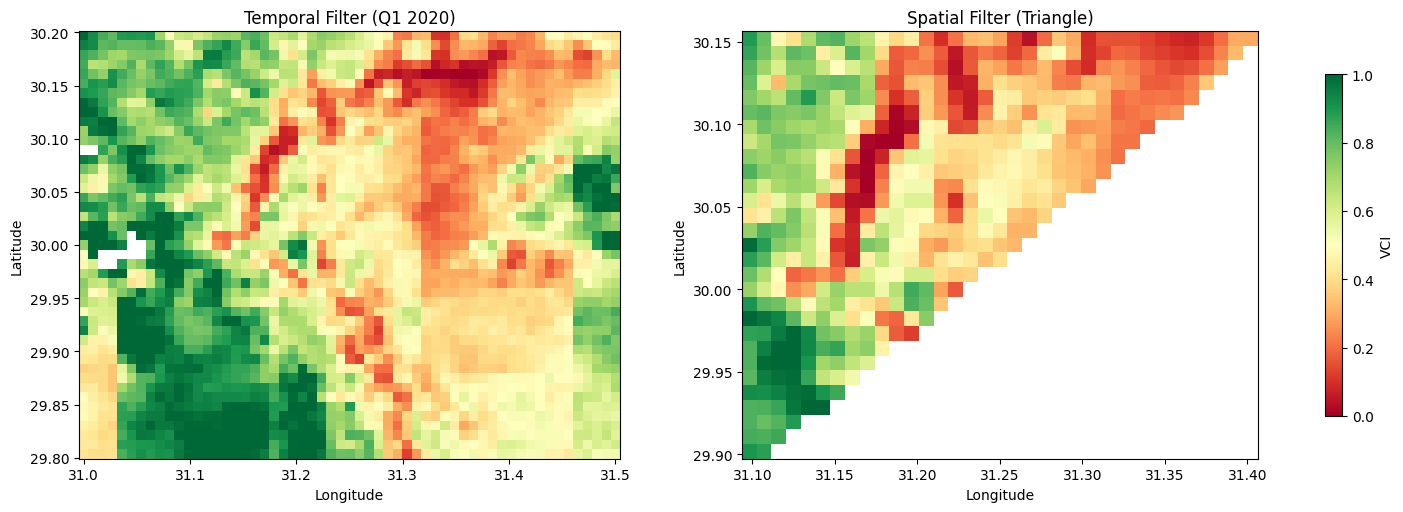

In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, path, title in [
    (axes[0], "vci_q1_mean.tif", "Temporal Filter (Q1 2020)"),
    (axes[1], "vci_clipped.tif", "Spatial Filter (Triangle)"),
]:
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
    img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                    cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.colorbar(img, ax=axes, label="VCI", shrink=0.8)
plt.show()

## 4. Band Math and Pixel Transformations

The `apply` process runs a function on every pixel. You can also use Python operators directly on cubes.

In [ ]:
# Load Q1 data
q1 = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-01-01", "2020-03-31"],
)
mean_q1 = q1.reduce_dimension(dimension="time", reducer="mean")

# Apply a threshold — pixels < 0.35 are drought
drought_mask = mean_q1.apply(lambda x: x < 0.35)

# Download
drought_mask.download("drought_binary.tif", format="GTiff")
print("Drought mask downloaded.")

Drought mask downloaded.


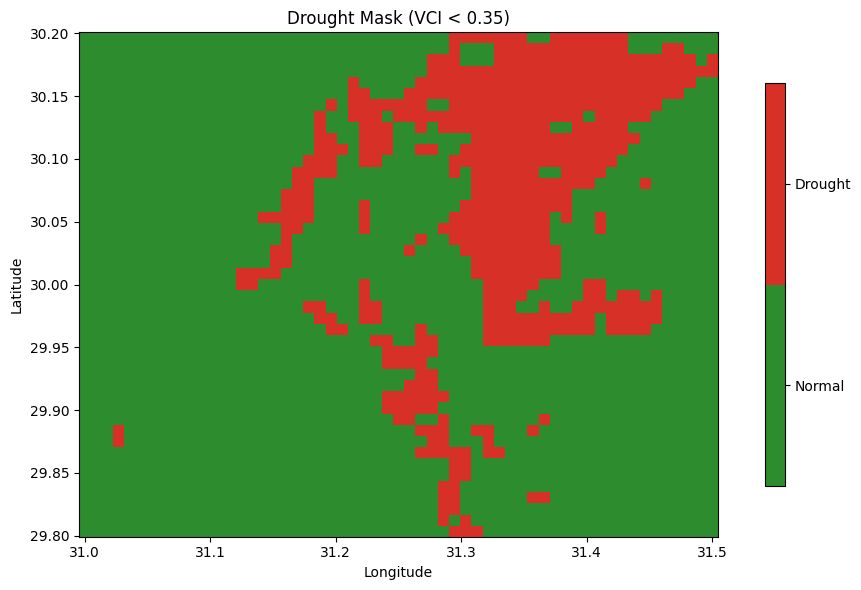

In [29]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 6))

with rasterio.open("drought_binary.tif") as src:
    data = src.read(1)
    bounds = src.bounds
cmap_bin = ListedColormap(["#2d8c2d", "#d73027"])
img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                cmap=cmap_bin, vmin=0, vmax=1, interpolation="nearest")
ax.set_title("Drought Mask (VCI < 0.35)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cbar = plt.colorbar(img, ax=ax, ticks=[0.25, 0.75], shrink=0.8)
cbar.ax.set_yticklabels(["Normal", "Drought"])
plt.tight_layout()
plt.show()

## 5. Cube Arithmetic — Operations Between Two Cubes

You can use standard Python operators (`-`, `+`, `*`, `/`) directly between two data cubes. The backend aligns them spatially and applies the operation pixel-by-pixel.

This is useful for:
- **Change detection** — subtract two time periods to find where conditions improved or degraded
- **Anomaly computation** — subtract a long-term mean from a current observation
- **Relative change** — divide current by baseline to get a ratio
- **Composite indices** — combine indicators from different collections

### Seasonal Change Detection (Subtraction)

Subtract Q1 from Q3 vegetation to see where conditions improved (positive) or degraded (negative) over the growing season.

In [ ]:
# Load two periods over the same area
q1 = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-01-01", "2020-03-31"],
)
q3 = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-07-01", "2020-09-30"],
)

# Reduce each to a single time step
mean_q1 = q1.reduce_dimension(dimension="time", reducer="mean")
mean_q3 = q3.reduce_dimension(dimension="time", reducer="mean")

# Subtract: positive = improvement, negative = degradation
change = mean_q3 - mean_q1

change.download("vci_change_q1_to_q3.tif", format="GTiff")
print("Seasonal change map downloaded.")

Seasonal change map downloaded.


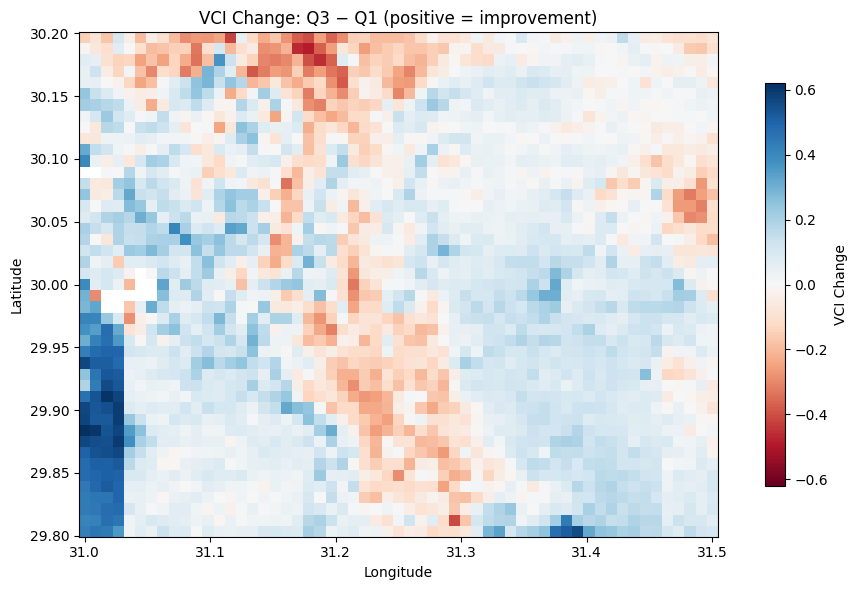

In [31]:
with rasterio.open("vci_change_q1_to_q3.tif") as src:
    data = src.read(1)
    bounds = src.bounds
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

fig, ax = plt.subplots(figsize=(10, 6))
vmax = max(abs(np.nanmin(data)), abs(np.nanmax(data)))
img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("VCI Change: Q3 − Q1 (positive = improvement)")
plt.colorbar(img, ax=ax, label="VCI Change", shrink=0.8)
plt.tight_layout()
plt.show()

### Relative Change (Division)

Divide Q3 by Q1 to get the relative change ratio. Values > 1 indicate improvement, < 1 indicate degradation.

In [32]:
# Ratio: Q3 / Q1
ratio = mean_q3 / mean_q1

ratio.download("vci_ratio_q3_over_q1.tif", format="GTiff")
print("Ratio map downloaded.")

Ratio map downloaded.


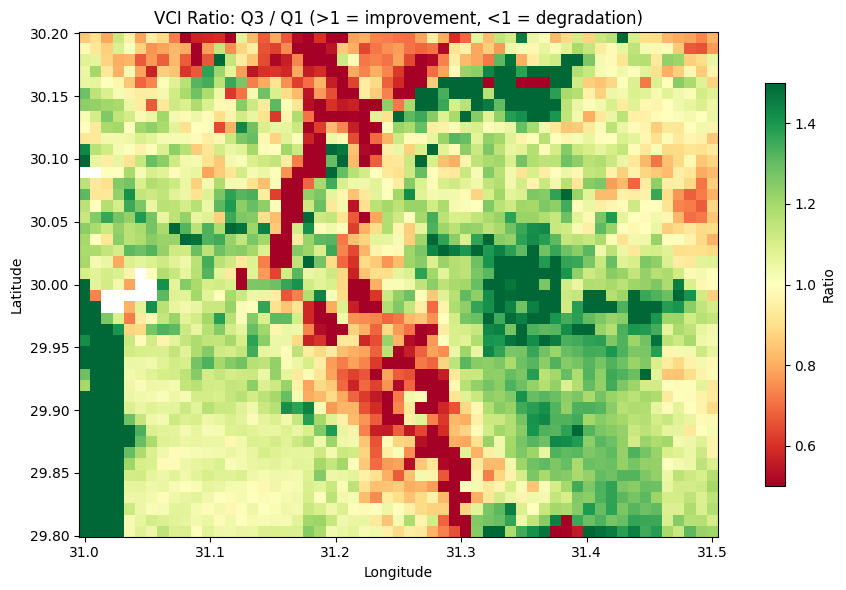

In [33]:
with rasterio.open("vci_ratio_q3_over_q1.tif") as src:
    data = src.read(1)
    bounds = src.bounds
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

fig, ax = plt.subplots(figsize=(10, 6))
img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                cmap="RdYlGn", vmin=0.5, vmax=1.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("VCI Ratio: Q3 / Q1 (>1 = improvement, <1 = degradation)")
plt.colorbar(img, ax=ax, label="Ratio", shrink=0.8)
plt.tight_layout()
plt.show()

### Weighted Combination (Multiplication & Addition)

Combine two periods with different weights to create a weighted composite — for example, weighting recent observations more heavily.

In [34]:
# Weighted average: 30% Q1 + 70% Q3 (weight recent data more)
weighted = (mean_q1 * 0.3) + (mean_q3 * 0.7)

weighted.download("vci_weighted_composite.tif", format="GTiff")
print("Weighted composite downloaded.")

Weighted composite downloaded.


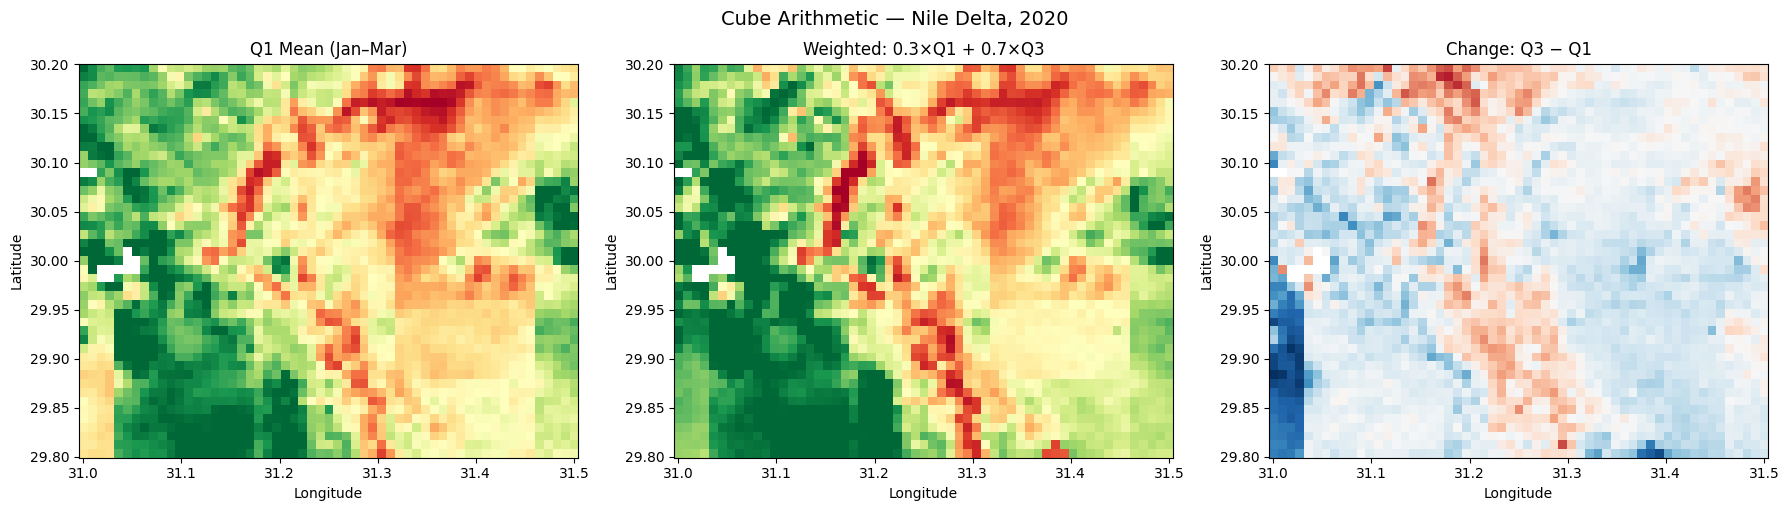

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, path, title in [
    (axes[0], "vci_q1_mean.tif", "Q1 Mean (Jan–Mar)"),
    (axes[1], "vci_weighted_composite.tif", "Weighted: 0.3×Q1 + 0.7×Q3"),
]:
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
    img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                    cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Show the change map for reference
with rasterio.open("vci_change_q1_to_q3.tif") as src:
    data = src.read(1)
    bounds = src.bounds
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)
vmax = max(abs(np.nanmin(data)), abs(np.nanmax(data)))
img2 = axes[2].imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                      cmap="RdBu", vmin=-vmax, vmax=vmax)
axes[2].set_title("Change: Q3 − Q1")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")

plt.suptitle("Cube Arithmetic — Nile Delta, 2020", fontsize=14)
plt.tight_layout()
plt.show()

### Operators Reference

| Operator | Example | Use Case |
|----------|---------|----------|
| `-` | `cube_a - cube_b` | Change detection, anomalies |
| `+` | `cube_a + cube_b` | Composite indices, accumulation |
| `*` | `cube_a * 0.5` or `cube_a * cube_b` | Weighting, scaling, masking |
| `/` | `cube_a / cube_b` | Ratios, normalization |
| `<`, `>`, `==` | `cube_a < 0.35` | Thresholds, binary masks |

## 6. Masking

Masking replaces pixels based on a condition. Two approaches:

- **`mask`** — use a raster mask (data cube). Pixels where the mask is non-zero/non-null get replaced.
- **`mask_polygon`** — use a GeoJSON geometry. Pixels outside (or inside) the polygon get replaced.

In [ ]:
# Create a drought mask from VCI < 0.35
q1 = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-01-01", "2020-03-31"],
)
mean_q1 = q1.reduce_dimension(dimension="time", reducer="mean")

# Build the mask: 1 where VCI < 0.35 (drought), 0 where healthy
drought_mask = mean_q1.apply(lambda x: x < 0.35)

# Apply mask: pixels where mask is non-zero (drought) get replaced with NaN
healthy_only = mean_q1.mask(drought_mask)
healthy_only.download("vci_healthy_only.tif", format="GTiff")
print("Masked cube downloaded (drought pixels removed).")

Masked cube downloaded (drought pixels removed).


In [48]:
# Mask with polygon — keep only pixels inside a region
region = {
    "type": "Polygon",
    "coordinates": [[
        [31.15, 29.95], [31.15, 30.1],
        [31.35, 30.1], [31.35, 29.95],
        [31.15, 29.95]
    ]]
}

# inside=True replaces pixels INSIDE the polygon
# inside=False (default) replaces pixels OUTSIDE the polygon
masked_outside = mean_q1.mask_polygon(region, inside=False)
masked_outside.download("vci_polygon_masked.tif", format="GTiff")
print("Polygon-masked cube downloaded.")

Polygon-masked cube downloaded.


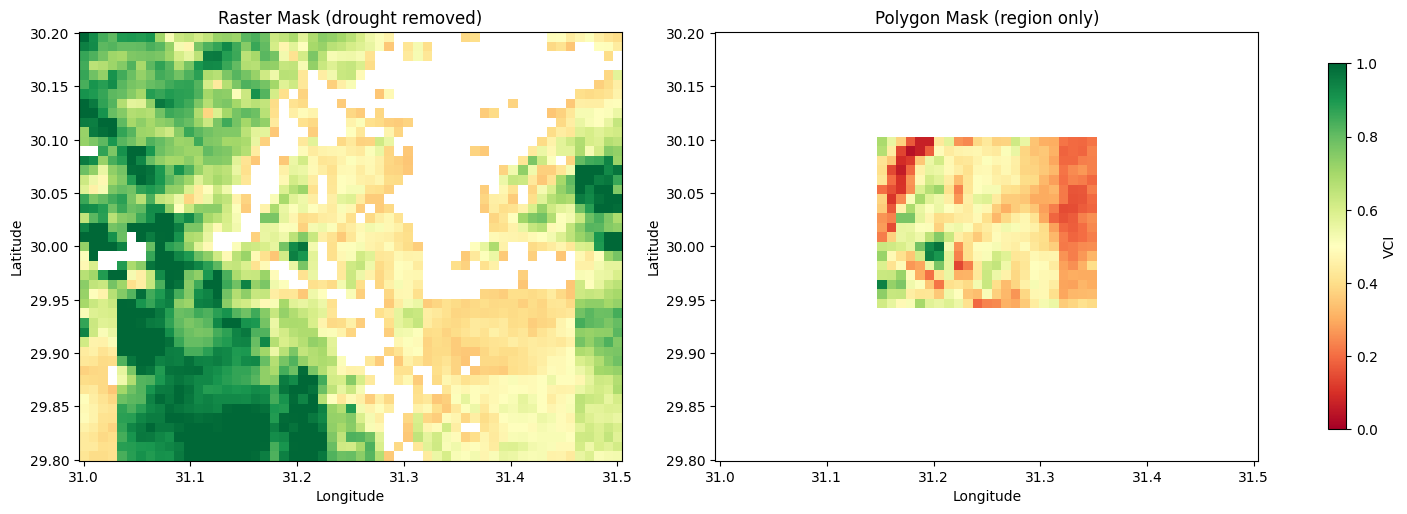

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, path, title in [
    (axes[0], "vci_healthy_only.tif", "Raster Mask (drought removed)"),
    (axes[1], "vci_polygon_masked.tif", "Polygon Mask (region only)"),
]:
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
    img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                    cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.colorbar(img, ax=axes, label="VCI", shrink=0.8)
plt.show()

## 7. Merging Data Cubes

The `merge_cubes` process combines two data cubes. Common use cases:

- **Different bands** → merged side-by-side
- **Different time periods** → concatenated along time
- **Same structure** → requires an `overlap_resolver` callback

Here we demonstrate stacking two temporal summaries (Q1 and Q3 means) into a single multi-band cube by adding a custom dimension label to each before merging.

In [ ]:
# Load two separate quarters
q1_cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-01-01", "2020-03-31"],
)
q3_cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-07-01", "2020-09-30"],
)

# Reduce each to temporal mean
mean_q1 = q1_cube.reduce_dimension(dimension="time", reducer="mean")
mean_q3 = q3_cube.reduce_dimension(dimension="time", reducer="mean")

# Add a "period" dimension label to each
q1_labeled = mean_q1.add_dimension(name="period", label="Q1_Jan_Mar")
q3_labeled = mean_q3.add_dimension(name="period", label="Q3_Jul_Sep")

# Merge the two cubes
merged = connection.datacube_from_process(
    process_id="merge_cubes",
    cube1=q1_labeled,
    cube2=q3_labeled,
)

# Download as multi-band GeoTIFF
merged.download("vci_q1_vs_q3.tif", format="GTiff")
print("Merged cube downloaded (2 bands: Q1 and Q3).")

Merged cube downloaded (2 bands: Q1 and Q3).


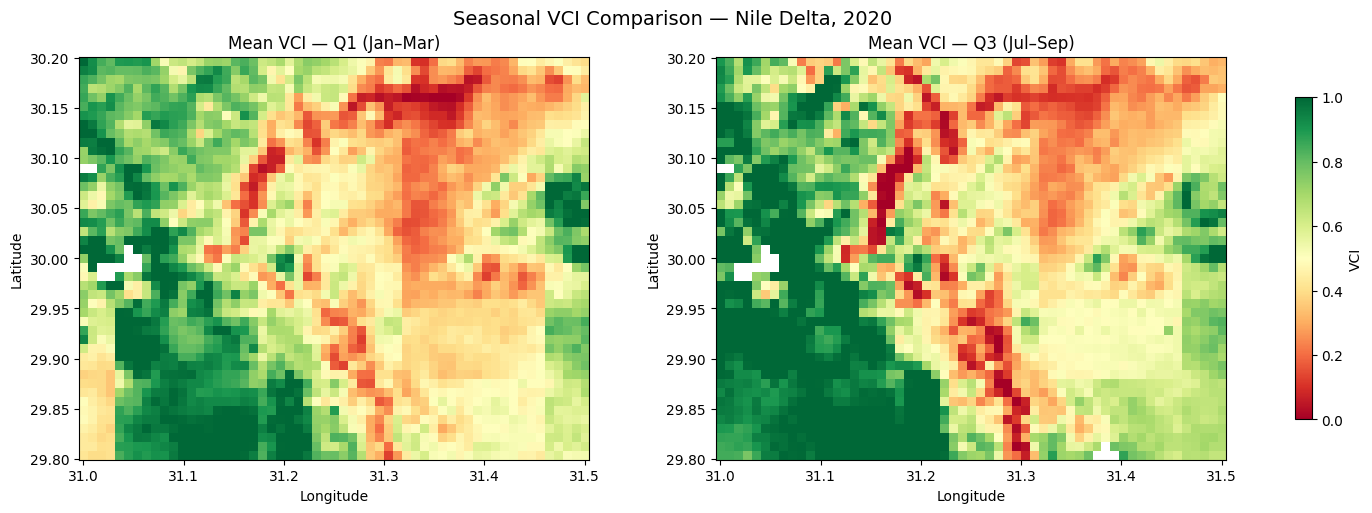

In [61]:
# Visualize both periods side by side
with rasterio.open("vci_q1_vs_q3.tif") as src:
    n_bands = src.count
    bounds = src.bounds

    fig, axes = plt.subplots(1, min(n_bands, 2), figsize=(14, 5), constrained_layout=True)
    if n_bands == 1:
        axes = [axes]
    labels = ["Q1 (Jan–Mar)", "Q3 (Jul–Sep)"]

    for i in range(min(n_bands, 2)):
        data = src.read(i + 1)
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
        img = axes[i].imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                             cmap="RdYlGn", vmin=0, vmax=1)
        axes[i].set_title(f"Mean VCI — {labels[i]}")
        axes[i].set_xlabel("Longitude")
        axes[i].set_ylabel("Latitude")

plt.colorbar(img, ax=axes, label="VCI", shrink=0.8)
plt.suptitle("Seasonal VCI Comparison — Nile Delta, 2020", fontsize=14)
plt.show()

## 8. Spatial Resampling

The `resample_spatial` process changes the spatial resolution of a data cube. Each pixel in the output grid is computed from the original pixels that fall within it, using a chosen method (e.g., `average` takes the mean, `near` picks the nearest value).

This is useful for:
- **Aligning datasets** — when combining two collections at different native resolutions
- **Reducing data volume** — coarser grids mean fewer pixels to process and store

Available methods: `near` (nearest neighbor), `bilinear`, `cubic`, `average`, `mode`, `min`, `max`, `median`

In [ ]:
# Load a cube over the full Nile Delta region
resample_cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent=bbox,
    temporal_extent=["2020-01-01", "2020-03-31"],
)
mean_resample = resample_cube.reduce_dimension(dimension="time", reducer="mean")

# Resample to coarser resolution (0.05 degrees ≈ 5 km)
resampled = mean_resample.resample_spatial(resolution=0.05, method="average")

# Download both for comparison
mean_resample.download("vci_original_res.tif", format="GTiff")
resampled.download("vci_resampled.tif", format="GTiff")
print("Original and resampled cubes downloaded.")

Original and resampled cubes downloaded.


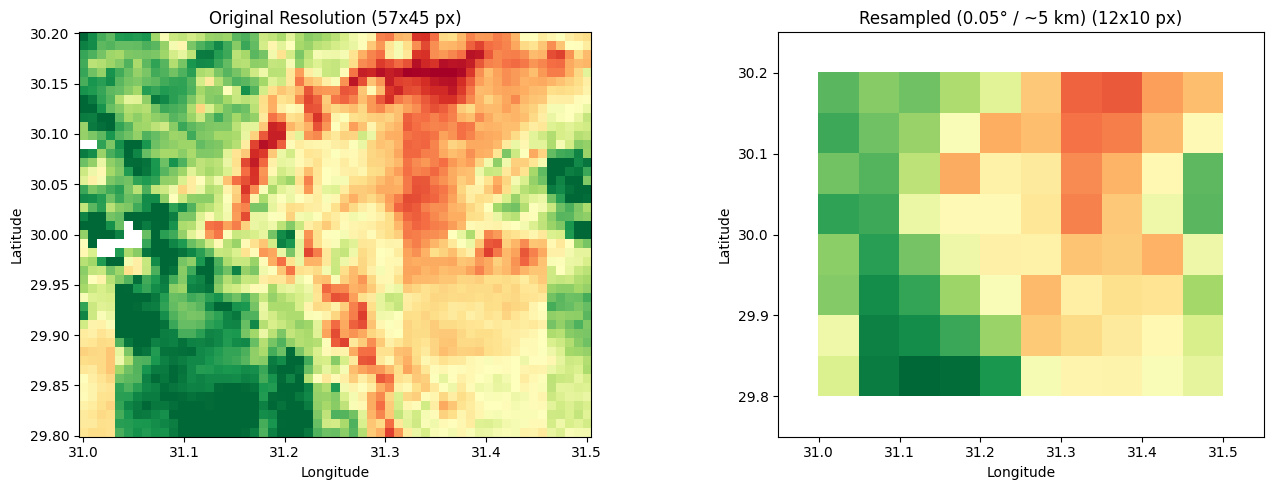

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, title in [
    (axes[0], "vci_original_res.tif", "Original Resolution"),
    (axes[1], "vci_resampled.tif", "Resampled (0.05° / ~5 km)"),
]:
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
        ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                  cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"{title} ({data.shape[1]}x{data.shape[0]} px)")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

## 9. Spatial Convolution

The `apply_kernel` process applies a spatial convolution filter. Common uses include smoothing, edge detection, and noise reduction.

In [69]:
# Apply a 3x3 mean smoothing kernel
smoothing_kernel = [
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1],
]

smoothed = mean_resample.apply_kernel(
    kernel=smoothing_kernel,
    factor=1.0 / 9.0,
)

smoothed.download("vci_smoothed.tif", format="GTiff")
print("Smoothed cube downloaded.")

Smoothed cube downloaded.


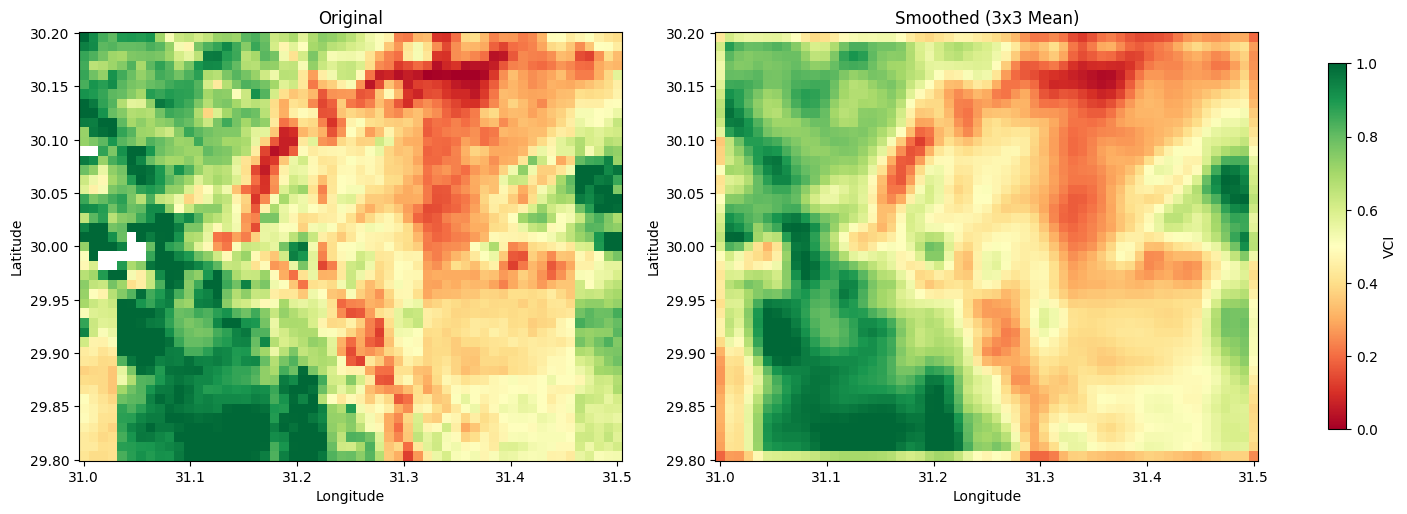

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, path, title in [
    (axes[0], "vci_original_res.tif", "Original"),
    (axes[1], "vci_smoothed.tif", "Smoothed (3x3 Mean)"),
]:
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
    img = ax.imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                    cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.colorbar(img, ax=axes, label="VCI", shrink=0.8)
plt.show()

## 10. Temporal Aggregation

The `aggregate_temporal_period` process groups timesteps into periods and applies a reducer.

Supported periods: `hour`, `day`, `week`, `dekad`, `month`, `season`, `tropical-season`, `year`, `decade`

In [ ]:
# Load a full year
year_cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent={"west": 31.2, "east": 31.35, "south": 30.0, "north": 30.1},
    temporal_extent=["2020-01-01", "2020-12-31"],
)

# Aggregate to seasonal means
seasonal = year_cube.aggregate_temporal_period(
    period="season",
    reducer="mean",
)

seasonal.download(
    "vci_seasonal_2020.tif",
    format="GTiff",
    options={"flatten_timestamps": True},
)
print("Seasonal VCI downloaded.")

Seasonal VCI downloaded.


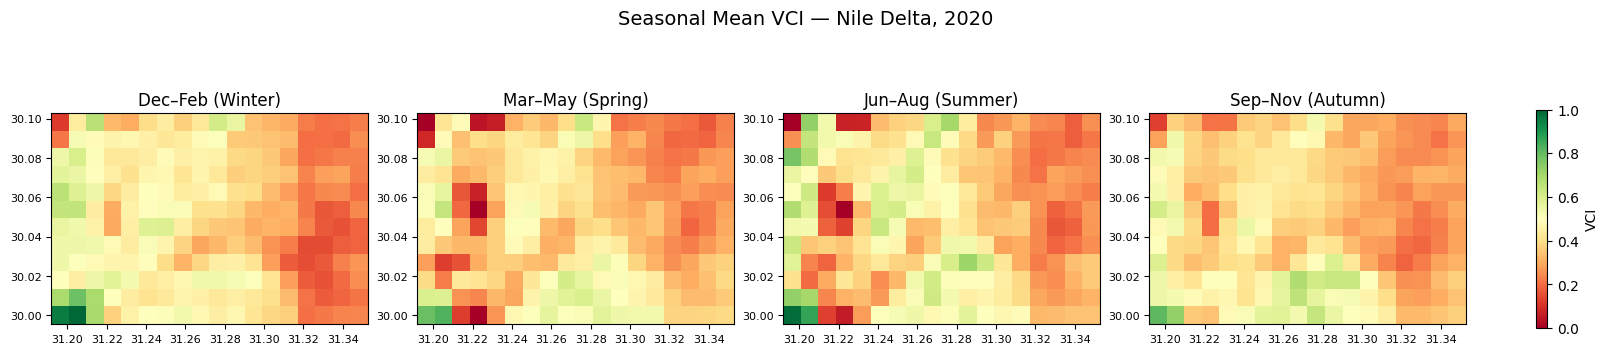

In [77]:
# Visualize seasonal maps
with rasterio.open("vci_seasonal_2020.tif") as src:
    n_bands = src.count
    bounds = src.bounds

    season_labels = ["Dec–Feb (Winter)", "Mar–May (Spring)", "Jun–Aug (Summer)", "Sep–Nov (Autumn)"]
    cols = min(n_bands, 4)
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4), constrained_layout=True)
    if cols == 1:
        axes = [axes]

    for i in range(cols):
        data = src.read(i + 1)
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
        img = axes[i].imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                             cmap="RdYlGn", vmin=0, vmax=1)
        axes[i].set_title(season_labels[i] if i < len(season_labels) else f"Band {i+1}")
        axes[i].tick_params(labelsize=8)

fig.colorbar(img, ax=axes, label="VCI", shrink=0.6)
fig.suptitle("Seasonal Mean VCI — Nile Delta, 2020", fontsize=14)
plt.show()

## Summary

In this tutorial, you learned the core data cube operations:

| Operation | Process | Use Case |
|-----------|---------|----------|
| **Filter temporal** | `filter_temporal` | Narrow time range |
| **Filter spatial** | `filter_spatial` | Clip to polygon |
| **Band math** | `apply`, operators (`+`, `-`, `*`, `<`) | Thresholds, scaling, indices |
| **Cube arithmetic** | `-`, `+`, `*`, `/` between cubes | Change detection, ratios, composites |
| **Raster mask** | `mask` | Remove pixels by condition |
| **Polygon mask** | `mask_polygon` | Clip to geometry, keep inside/outside |
| **Merge cubes** | `merge_cubes` + `add_dimension` | Combine periods or collections |
| **Resample** | `resample_spatial` | Change resolution |
| **Convolution** | `apply_kernel` | Smoothing, edge detection |
| **Temporal aggregation** | `aggregate_temporal_period` | Monthly, seasonal, yearly means |

These operations can be chained together to build complex analysis pipelines.

### Previous Tutorials

- **[Getting Started](01_getting_started.ipynb)** — Connection, authentication, first data cube
- **[NDVI Time Series](02_ndvi_time_series.ipynb)** — Vegetation monitoring over time
- **[Zonal Statistics](03_zonal_statistics.ipynb)** — Aggregating data over regions
- **[Climate Risk (CRTB)](04_climate_risk_crtb.ipynb)** — Hazard and vulnerability assessment
- **[Planting Recommendations](05_planting_recommendations.ipynb)** — Agricultural planning with PLAN-T